**Uczenie Głębokie (laboratorium)**

Dominik Filipiak

`df[🏒]amu.edu.pl`

Materiały zawierają wybrane fragmenty materiałów pomocniczych, które przygotowałem na potrzeby kursu Deep Learning dla studentów kierunku Machine Learning na Wydziale Matematyki, Informatyki i Mechaniki UW.

Cześć kodu bazuje na [notebookach z kursu Deep Learning](https://github.com/mim-ml-teaching/public-dnn-2024-25) dla studentów kierunku Machine Learning na Wydziale Matematyki, Informatyki i Mechaniki UW.

# Głębokie sieci neuronowe (cz. 2)

- AlexNet
- VGG
- ResNet
- FineTuning
- augmentations
- dataloaders

In [20]:
import shutil
from datetime import datetime
from pathlib import Path
from typing import Callable, Dict, List,Optional, Tuple

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, transforms
from tqdm import tqdm

matplotlib.style.use('dark_background')


### Przygotowanie

In [21]:
def get_torch_device() -> torch.device:
    """Funkcja pomocnicza do określenia na którym urządzeniu będziemy wykonywać obliczenia."""
    if torch.cuda.is_available():
        return torch.device("cuda") # NVIDIA GPU
    elif torch.backends.mps.is_available():
        return torch.device("mps")  # Apple Silicon - uwaga, nie wszysko działa. W razie kłopotów przejdź na CPU.
    else:
        return torch.device("cpu")  # CPU

In [22]:

activation_maps: Dict[str, torch.Tensor] = {}

def get_activation(name: str) -> Callable:
    """
    Zwraca hook do przechwytywania aktywacji dla danej warstwy.

    Args:
        name: unikalna nazwa warstwy (z `named_modules()`)

    Returns:
        Funkcja hooka do rejestrowania aktywacji.
    """
    def hook(model: nn.Module, input: torch.Tensor, output: torch.Tensor) -> None:
        activation_maps[name] = output.detach().cpu()
    return hook

def register_hooks(model: nn.Module) -> None:
    """
    Rejestruje forward hooki dla wszystkich warstw nn.Conv2d w modelu.

    Args:
        model: model sieci neuronowej
    """
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            module.register_forward_hook(get_activation(name))

def log_activation_maps(writer: SummaryWriter, model: nn.Module, input_img: torch.Tensor, epoch: int, device: torch.device) -> None:
    """
    Loguje mapy aktywacji do TensorBoard dla wszystkich warstw konwolucyjnych.

    Args:
        writer: obiekt SummaryWriter
        model: model z zarejestrowanymi hookami
        input_img: obraz wejściowy (tensor o wymiarach C x H x W)
        epoch: numer epoki (do logowania)
        device: urządzenie, na którym znajduje się model
    """
    model.eval()
    with torch.no_grad():
        model(input_img.unsqueeze(0).to(device))

    for name, activation in activation_maps.items():
        if activation.dim() == 4:
            # Batch x Channels x H x W → pokazujemy maks. 8 kanałów
            img_grid = torchvision.utils.make_grid(
                activation[0, :8].unsqueeze(1), normalize=True, scale_each=True
            )
            writer.add_image(f"Activations/{name}", img_grid, epoch)

def log_filters(writer: SummaryWriter, model: nn.Module, epoch: int) -> None:
    """
    Loguje wizualizacje filtrów wszystkich warstw nn.Conv2d do TensorBoard.

    Args:
        writer: obiekt SummaryWriter
        model: model sieci neuronowej
        epoch: numer epoki (do logowania)
    """
    conv_idx = 0
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            weights = module.weight.data.clone()

            # Normalizacja do [0, 1]
            weights = (weights - weights.min()) / (weights.max() - weights.min() + 1e-5)

            if weights.shape[1] in {1, 3}:
                writer.add_images(f"Conv{conv_idx}/filters", weights, epoch)
            else:
                writer.add_images(f"Conv{conv_idx}/filters_in0", weights[:, 0:1, :, :], epoch)

            conv_idx += 1

def log_weights_and_gradients(writer: SummaryWriter, model: nn.Module, epoch: int) -> None:
    """
    Loguje histogramy wag, biasów i ich gradientów dla wszystkich modułów modelu.

    Args:
        writer: obiekt SummaryWriter
        model: model sieci neuronowej
        epoch: numer epoki (do logowania)
    """
    for name, module in model.named_modules():
        if hasattr(module, "weight") and module.weight is not None:
            writer.add_histogram(f"Weights/{name}/weight", module.weight.data.cpu(), epoch)
            if module.weight.grad is not None:
                writer.add_histogram(f"Gradients/{name}/weight", module.weight.grad.cpu(), epoch)
        
        if hasattr(module, "bias") and module.bias is not None:
            writer.add_histogram(f"Weights/{name}/bias", module.bias.data.cpu(), epoch)
            if module.bias.grad is not None:
                writer.add_histogram(f"Gradients/{name}/bias", module.bias.grad.cpu(), epoch)

def count_params(model: nn.Module) -> int:
    """
    Zlicza liczbę parametrów w modelu.

    Args:
        model: instancja nn.Module

    Returns:
        Całkowita liczba parametrów w modelu.
    """
    return sum(p.numel() for p in model.parameters())

def log_predictions(
    writer: SummaryWriter,
    model: nn.Module,
    dataset: Dataset,
    epoch: int,
    class_names: List[str],
    device: torch.device
) -> None:
    """
    Loguje przykładowe predykcje modelu do TensorBoard.

    Args:
        writer: obiekt SummaryWriter
        model: wytrenowany model w trybie ewaluacyjnym
        dataset: zbiór danych (np. walidacyjny)
        epoch: numer epoki (do logowania)
        class_names: lista nazw klas (np. dataset.classes)
        device: urządzenie (np. torch.device('cuda'))
    """
    model.eval()
    images: List[torch.Tensor] = []
    labels: List[int] = []
    preds: List[int] = []

    with torch.no_grad():
        for i in range(8):
            x, y = dataset[i]
            output = model(x.unsqueeze(0).to(device))
            pred = output.argmax(dim=1).item()
            images.append(x)
            labels.append(y)
            preds.append(pred)

    # Rysuj obrazy z predykcjami
    fig, axs = plt.subplots(2, 4, figsize=(12, 6))
    axs = axs.flatten()

    for i, ax in enumerate(axs):
        img = images[i].permute(1, 2, 0)  # C x H x W → H x W x C
        img = img * 0.5 + 0.5  # denormalizacja (jeśli dane były normalizowane w [-1, 1])
        ax.imshow(img.numpy())
        ax.set_title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}")
        ax.axis('off')

    writer.add_figure("Predictions/Sample", fig, epoch)
    plt.close(fig)


In [23]:
def train_epoch(
    model: nn.Module,
    device: torch.device,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    writer: Optional[SummaryWriter] = None,
    log_histograms: bool = False
) -> Tuple[float, float]:
    """
    Trenuje model przez jedną epokę na zadanym zbiorze danych.

    Args:
        model: Model sieci neuronowej (w trybie treningowym).
        device: Urządzenie obliczeniowe (CPU / CUDA / MPS).
        loader: DataLoader zawierający dane treningowe.
        optimizer: Obiekt optymalizatora.
        epoch: Numer epoki (do logowania).
        writer: Obiekt SummaryWriter do logowania w TensorBoard.
        log_histograms: Czy logować histogramy wag i gradientów.

    Returns:
        Tuple zawierający średnią wartość funkcji straty oraz dokładność dla epoki.
    """
    model.train()
    total_loss = 0
    correct = 0

    for batch_idx, (data, target) in enumerate(tqdm(loader, desc=f"Train Epoch {epoch}")):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = nn.CrossEntropyLoss()(output, target)
        loss.backward()

        if log_histograms and writer:
            log_weights_and_gradients(writer, model, epoch)

        optimizer.step()

        total_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()

    acc = correct / len(loader.dataset)
    avg_loss = total_loss / len(loader)

    if writer:
        writer.add_scalar("Train/Loss", avg_loss, epoch)
        writer.add_scalar("Train/Accuracy", acc, epoch)
        example_input = loader.dataset[0][0].to(device)
        log_activation_maps(writer, model, example_input, epoch, device=device)
        log_filters(writer, model, epoch)

    return avg_loss, acc


def val_epoch(
    model: nn.Module,
    device: torch.device,
    loader: DataLoader,
    epoch: int,
    writer: Optional[SummaryWriter] = None
) -> Tuple[float, float]:
    """
    Ewaluacja modelu na zbiorze walidacyjnym lub testowym.

    Args:
        model: Model w trybie ewaluacyjnym.
        device: Urządzenie obliczeniowe.
        loader: DataLoader zawierający dane do ewaluacji.
        epoch: Numer epoki (do logowania).
        writer: Obiekt SummaryWriter do logowania (opcjonalnie).

    Returns:
        Tuple zawierający średnią wartość straty i dokładność.
    """
    model.eval()
    total_loss = 0
    correct = 0

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = nn.CrossEntropyLoss()(output, target)
            total_loss += loss.item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()

    acc = correct / len(loader.dataset)
    avg_loss = total_loss / len(loader)

    if writer:
        writer.add_scalar("Val/Loss", avg_loss, epoch)
        writer.add_scalar("Val/Accuracy", acc, epoch)
        log_predictions(writer, model, loader.dataset, epoch, loader.dataset.classes, device=device)

    return avg_loss, acc


def run_training(
    runs_dir: Path,
    device: torch.device,
    epochs: int,
    learning_rate: float,
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader
) -> None:
    """
    Uruchamia pełen proces treningu i walidacji modelu.

    Args:
        runs_dir: Ścieżka do katalogu, gdzie zapisywane będą logi TensorBoard.
        device: Urządzenie (CPU / CUDA / MPS).
        epochs: Liczba epok do przeprowadzenia treningu.
        learning_rate: Współczynnik uczenia.
        model: Model do trenowania (torch.nn.Module).
        train_loader: Dane treningowe.
        test_loader: Dane testowe lub walidacyjne.
    """
    register_hooks(model)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    run_name = f"{model.__class__.__name__}_FashionMNIST_{str(datetime.now().timestamp())}"

    best_val_loss = torch.inf

    with SummaryWriter(runs_dir / run_name) as writer:
        writer.add_graph(model, train_loader.dataset[0][0].unsqueeze(0).to(device))

        for epoch in range(epochs):
            train_epoch(model, device, train_loader, optimizer, epoch, writer)
            val_loss, _ = val_epoch(model, device, test_loader, epoch, writer)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state_dict = model.state_dict()

        model.load_state_dict(best_state_dict)
        test_loss, test_acc = val_epoch(model, device, test_loader, epoch + 1, writer)

        writer.add_hparams(
            {
                "model": model.__class__.__name__,
                "lr": learning_rate,
                "epochs": epochs,
            },
            {
                "hparam/num_params": count_params(model),
                "hparam/test_loss": test_loss,
                "hparam/test_accuracy": test_acc
            },
            run_name=run_name
        )


In [24]:
transform = transforms.Compose([
    transforms.Resize(227),  # wymagane przez AlexNet
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),  # z 1 kanału do 3 kanałów (szarość -> RGB)
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

train_dataset = datasets.FashionMNIST(root="data", train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

100%|██████████| 26421880/26421880 [00:01<00:00, 25652436.09it/s]


Extracting data\FashionMNIST\raw\train-images-idx3-ubyte.gz to data\FashionMNIST\raw



100%|██████████| 29515/29515 [00:00<00:00, 593393.23it/s]


Extracting data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to data\FashionMNIST\raw



100%|██████████| 4422102/4422102 [00:00<00:00, 11648215.62it/s]


Extracting data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to data\FashionMNIST\raw



100%|██████████| 5148/5148 [00:00<?, ?it/s]

Extracting data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to data\FashionMNIST\raw



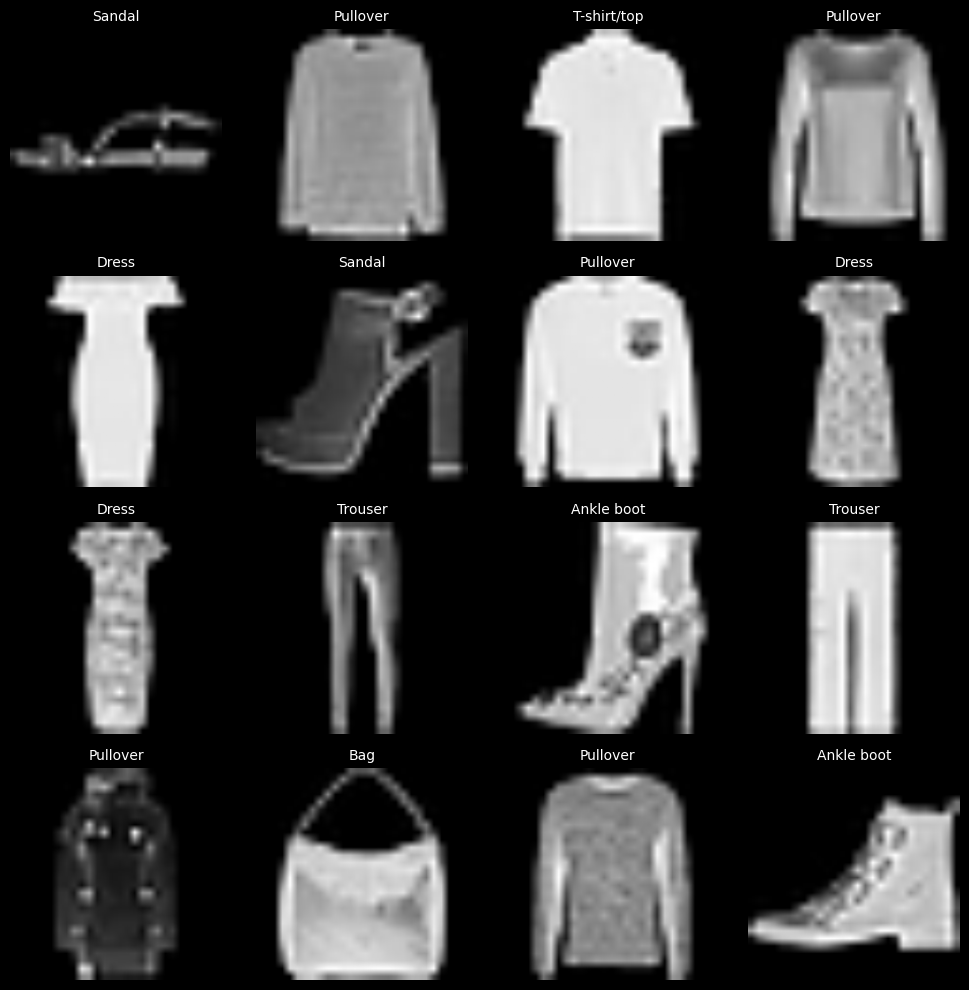

In [25]:
def show_sample_images(dataset: Dataset, class_names: List[str], num_images: int = 16) -> None:
    """
    Wyświetla siatkę przykładowych obrazów z etykietami klas.

    Args:
        dataset: zbiór danych (np. train_dataset)
        class_names: lista nazw klas
        num_images: liczba obrazów do pokazania (musi być kwadratem: 4, 9, 16, ...)
    """
    assert int(np.sqrt(num_images))**2 == num_images, "num_images musi być kwadratem liczby całkowitej"

    indices = np.random.choice(len(dataset), num_images, replace=False)
    images, labels = zip(*[dataset[i] for i in indices])

    grid_size = int(np.sqrt(num_images))
    fig, axs = plt.subplots(grid_size, grid_size, figsize=(grid_size * 2.5, grid_size * 2.5))
    axs = axs.flatten()

    for img, label, ax in zip(images, labels, axs):
        img_disp = img.permute(1, 2, 0) * 0.5 + 0.5  # denormalizacja
        ax.imshow(img_disp.numpy())
        ax.set_title(class_names[label], fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_sample_images(train_dataset, train_dataset.classes)


## AlexNet

**AlexNet** to jedna z pierwszych głębokich sieci, która osiągnęła przełomowe wyniki w konkursie ImageNet w 2012 roku. Wprowadziła m.in.:
- warstwy ReLU,
- dropout dla regularizacji,
- trening równoległy na dwóch GPU (historycznie ważne!),
- 5 warstw konwolucyjnych + 3 w pełni połączone.

Dla ułatwienia analizy zastosowano nazewnictwo z [wykładu dr. Pałubickiego](https://wp.faculty.wmi.amu.edu.pl/DL6.pdf).

<details>
  <summary>Architektura</summary>
  Więcej przeczytasz w [oryginalnym artykule](https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf), z którego pochodzi ponizszy obrazek.

  ![Source: https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf](https://production-media.paperswithcode.com/methods/Screen_Shot_2020-06-22_at_6.35.45_PM.png)
</details>

<details>
  <summary>Tabelka z wykładu z analizą rozmiaru wejść/wyjść</summary>
  W oryginalne było 1000 klas na wyjściu - my mamy tylko 10, stąd zmiana na końcu.

  ![Source: https://wp.faculty.wmi.amu.edu.pl/DL6.pdf](figures/alexnet_lecture.png)
</details>



In [7]:
class AlexNet(nn.Module):
    def __init__(self, num_input_channels=3, num_classes=1000, dropout=.5):
        super(AlexNet, self).__init__()
        
        self.conv1 = nn.Conv2d(num_input_channels, 64, kernel_size=11, stride=4, padding=2)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2)
        
        self.conv2 = nn.Conv2d(64, 192, kernel_size=5, padding=2)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(kernel_size=3, stride=2)
        
        self.conv3 = nn.Conv2d(192, 384, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU(inplace=True)
        
        self.conv4 = nn.Conv2d(384, 256, kernel_size=3, padding=1)
        self.relu4 = nn.ReLU(inplace=True)
        
        self.conv5 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.relu5 = nn.ReLU(inplace=True)
        self.pool5 = nn.MaxPool2d(kernel_size=3, stride=2)

        self.flatten = nn.Flatten(start_dim=1)

        self.dropout6 = nn.Dropout(p=dropout)
        self.fc6 = nn.Linear(9216, 4096)
        self.relu6 = nn.ReLU(inplace=True)

        self.dropout7 = nn.Dropout(p=dropout)
        self.fc7 = nn.Linear(4096, 4096)
        self.relu7 = nn.ReLU(inplace=True)

        self.fc8 = nn.Linear(4096, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.relu3(self.conv3(x))
        x = self.relu4(self.conv4(x))
        x = self.pool5(self.relu5(self.conv5(x)))
        x = self.relu6(self.fc6(self.dropout6(self.flatten(x))))
        x = self.relu7(self.fc7(self.dropout7(x)))
        x = self.fc8(x)
        
        return x

In [8]:
# uwaga - usuwa poprzednie eksperymenty!
runs_dir = Path("runs")
shutil.rmtree(runs_dir)

In [9]:
device = get_torch_device()

epochs = 5
learning_rate = 1e-3
num_classes = 10

model = AlexNet(num_classes=num_classes).to(device)
run_training(runs_dir, device, epochs, learning_rate, model)

Train Epoch 4: 100%|██████████| 938/938 [01:44<00:00,  8.98it/s]


## VGG

**VGG** (np. VGG-16, VGG-19) zaproponowała, aby używać **bardzo małych jąder konwolucyjnych (3x3)**, ale **wiele warstw** — nawet do 19.

- VGG wykorzystuje wyłącznie konwolucje 3×3 z krokiem 1 i paddingiem 1, co pozwala zachować rozmiar aktywacji. Przykładowy blok: `Conv → ReLU → Conv → ReLU → MaxPool`. 
- Architektura ta znacząco zwiększyła głębokość sieci bez zmiany istotnych hiperparametrów i była fundamentem dalszych konstrukcji (np. ResNet).
- Pomimo swojej skuteczności, sieć VGG ma dużą liczbę parametrów (np. VGG-16 ≈ 138M), co wpływa na czas trenowania i wymaga GPU z dużą pamięcią.
- Sieć zawdzięcza swoją nazwę legendarnej grupie [Visual Geometry Group](https://www.robots.ox.ac.uk/~vgg/) na Uniwersytecie Oksfordzkim. Grupę VGG prowadzi A. Zisserman, znany jako współautor jednego z klasyków wizji komputerowej: [Multiple View Geometry in Computer Vision](https://www.robots.ox.ac.uk/~vgg/hzbook/).

Więcej przeczytasz w oryginalnym artykule: [Very Deep Convolutional Networks for Large-scale Image Recognition](https://arxiv.org/pdf/1409.1556).



<details>
  <summary>Architektura VGG-16 i VGG-19 z wykładu</summary>
  
  ![Source: https://wp.faculty.wmi.amu.edu.pl/DL6.pdf](figures/vgg_lecture.png)
</details>

In [10]:
class VGGBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_convs):
        super().__init__()
        layers = []
        for _ in range(num_convs):
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
            layers.append(nn.ReLU(inplace=True))
            in_channels = out_channels
        layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

class VGG(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            VGGBlock(3, 64, 2),
            VGGBlock(64, 128, 2),
            VGGBlock(128, 256, 3),
            VGGBlock(256, 512, 3),
            VGGBlock(512, 512, 3)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [11]:
model = VGG(num_classes=10).to(device)
run_training(runs_dir, device, epochs, learning_rate, model)

Train Epoch 4: 100%|██████████| 938/938 [18:20<00:00,  1.17s/it]


# ResNet


**ResNet** (Residual Network) wprowadziła tzw. **połączenia resztkowe** (ang. residual connections), które umożliwiają trenowanie bardzo głębokich sieci bez problemu zanikania gradientu.

Zamiast uczyć się funkcji $H(x)$, uczymy się **reszty** (ang. residual): $F(x) = H(x) - x$.

Zachęcam do zerknięcia do oryginalnego artykułu: [Deep Residual Learning for Image Recognition](https://arxiv.org/pdf/1512.03385).

---

### Problem: degradacja podczas pogłębiania sieci

- Dodawanie kolejnych warstw nie zawsze działa, nawet jeśli zastosujemy techniki przeciwdziałające zanikaniu gradientów: poprawnej inicjalizacji wag, zastosowania batch normalization itd.
- Można by przypuszczać, że to przeuczenie — ale wtedy błąd treningowy powinien być bardzo niski.
- Tymczasem dokładanie warstw zwiększa także błąd treningowy, co oznacza, że to nie przeuczenie, lecz _zjawisko degradacji dokładności trenowania_.

---

### Rozwiązanie: połączenia resztkowe (*residual connections*)

- Chcemy nauczyć się odwzorowania $H(x)$ dla danego wejścia $x$.
- Zamiast tego uczmy się $F(x) = H(x) - x$, co oznacza, że końcowe odwzorowanie to $H(x) = F(x) + x$ — mówimy wtedy o **odwzorowaniu resztkowym** (analogicznie do reszt w metodach numerycznych).
- Innymi słowy: **na wyjście każdego bloku dodajemy jego wejście**.
- Eksperymentalnie okazuje się, że łatwiej nauczyć się odwzorowania resztkowego $F(x)$ niż bezpośrednio $H(x)$.
- To znowu przykład przekształcenia matematycznego równoważnego, ale mającego różne konsekwencje optymalizacyjne (jak np. sztuczka `LogSumExp`, o której mówiliśmy wcześniej).
- Ten _jeden prosty trik_ eliminuje degradację dokładności treningu, a także poprawia dokładność testową.
- Co więcej odbywa się to bez zwiększania liczby parametrów, o ile używamy odwzorowania tożsamościowego (bez dopasowania wymiarów przez konwolucje 1×1).

---

<details>
  <summary>Blok resztkowy</summary>


Blok resztkowy można zapisać jako: `y = F(x) + x`, gdzie `F(x)` to transformacja (np. dwa Conv + ReLU), a `x` to shortcut connection. 
Umożliwia to lepszy przepływ gradientów w głębokich sieciach i rozwiązuje problem degradacji wydajności w bardzo głębokich architekturach.
Intuicja jest prosta - skrót pozwala na szybki dostęp do "nietkniętego" gradientu z odległych warstw.
Dla głębszych sieci używa się tzw. bottlenecków: `1x1 → 3x3 → 1x1` z redukcją kanałów, co zmniejsza liczbę parametrów.


  ![Źródło: https://arxiv.org/pdf/1512.03385](figures/resnet_paper.png)
</details>

<details>
  <summary>Architektura ResNet z wykładu</summary>

  ![Źródło: https://wp.faculty.wmi.amu.edu.pl/DL6.pdf](figures/resnet_lecture.png)
</details>

In [12]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):
        identity = x
        if self.downsample:
            identity = self.downsample(x)

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out += identity
        out = self.relu(out)
        return out

class ResNet18Mini(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, 64, 2)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = [ResidualBlock(in_channels, out_channels, stride, downsample)]
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn(self.conv(x)))
        x = self.pool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


In [13]:
model = ResNet18Mini(num_classes=10).to(device)
run_training(runs_dir, device, epochs, learning_rate, model)


Train Epoch 4: 100%|██████████| 938/938 [04:05<00:00,  3.83it/s]


## Fine-tuning i Transfer Learning

Zamiast trenować sieć od zera, często korzystamy z **transfer learningu** – czyli używamy wcześniej wytrenowanych wag i dostosowujemy je do naszego zadania.

Dwa typy:
1. **Feature extractor** – zamrażamy wszystkie warstwy i trenujemy tylko ostatnią warstwę.
2. **Fine-tuning** – odblokowujemy niektóre (lub wszystkie) warstwy i trenujemy dalej na naszym zbiorze danych.

Dolne warstwy uczą się cech niskopoziomowych (np. krawędzie, tekstury), które są uniwersalne między zadaniami. 
Wyższe warstwy są bardziej zadaniowo-specyficzne, dlatego transfer learning polega zwykle na zamrożeniu dolnych warstw i dostrojeniu górnych.

W PyTorch, zamrażamy parametry przez `param.requires_grad = False`, a nowe warstwy uczymy od zera.


In [ ]:
from torchvision.models import resnet18

def get_resnet18_feature_extractor(num_classes: int = 10) -> nn.Module:
    model = resnet18(weights='IMAGENET1K_V1')
    for param in model.parameters():
        param.requires_grad = False

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


In [15]:
def get_resnet18_finetune(num_classes: int = 10, unfreeze_from: str = 'layer4') -> nn.Module:
    model = resnet18(weights='IMAGENET1K_V1')
    
    # Zamrożenie wszystkich warstw
    for param in model.parameters():
        param.requires_grad = False
    
    # Odmrażamy wybraną warstwę i wyżej
    unfreeze = False
    for name, module in model.named_children():
        if name == unfreeze_from:
            unfreeze = True
        if unfreeze:
            for param in module.parameters():
                param.requires_grad = True

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


In [16]:
# Feature extractor
model = get_resnet18_feature_extractor(num_classes=10).to(device)

# Fine-tuning (np. od layer4)
# model = get_resnet18_finetune(num_classes=10, unfreeze_from='layer4').to(device)

run_training(runs_dir, device, epochs=5, learning_rate=1e-3, model=model)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/dfilipiak/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 94.1MB/s]
Train Epoch 4: 100%|██████████| 938/938 [02:02<00:00,  7.65it/s]


## Własne dane

Augmentacje pomagają sztucznie powiększyć zbiór danych i wprowadzić różnorodność. Stosowane losowo podczas trenowania, np.:


Augmentacje mogą być:
- **geometryczne**: `RandomCrop`, `HorizontalFlip`, `Affine`, `Rotation`
- **fotometryczne**: `ColorJitter`, `Grayscale`, `GaussianBlur`

Ich celem jest zwiększenie różnorodności danych treningowych i poprawa uogólnienia modelu. Augmentacje stosujemy najczęściej tylko na zbiorze treningowym.

- zauważ, że augmentacje mogą byc różne dla zbioru `train` i `val`/`test`
- w wielu problemach transformować trzeba nie tylko dane, ale również etykiety (np. w semantycznej segmentacji)

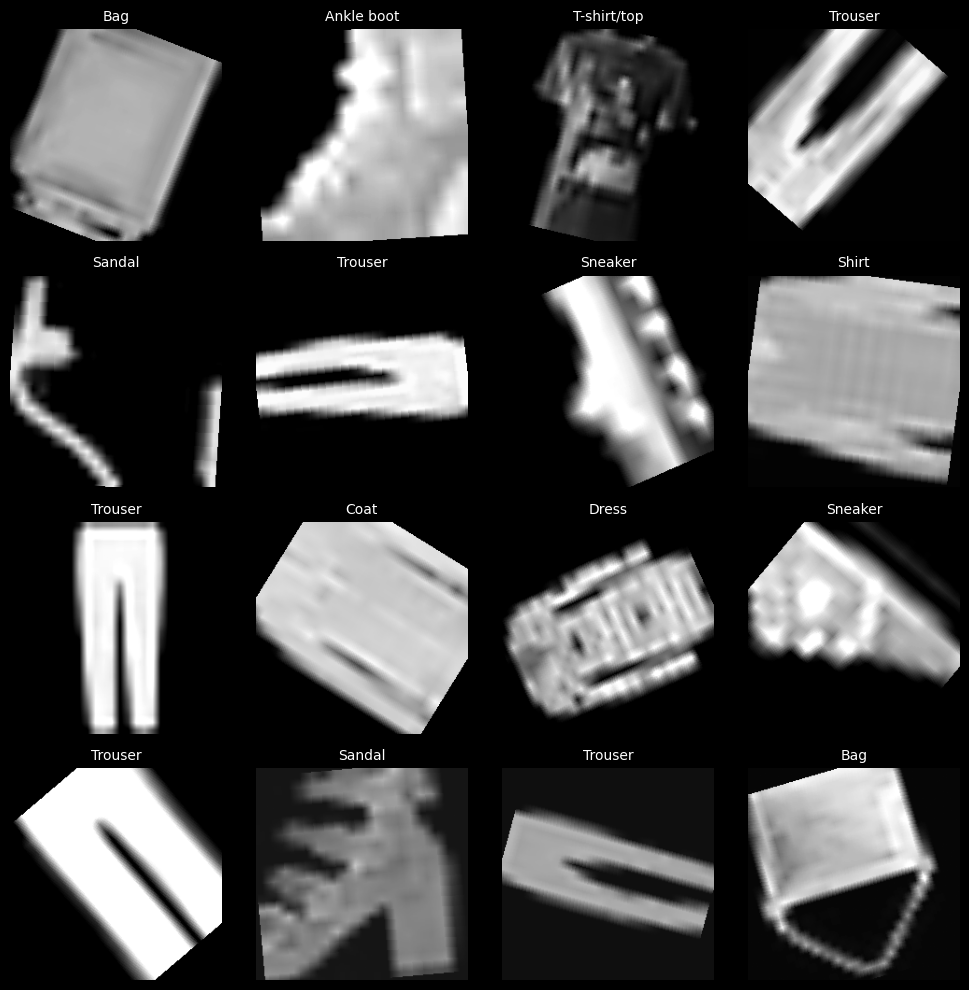

In [36]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(227),
    transforms.RandomRotation(degrees=180),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),  # z 1 kanału do 3 kanałów (szarość -> RGB)
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

test_transform = transforms.Compose([
    transforms.Resize(227),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),  # z 1 kanału do 3 kanałów (szarość -> RGB)
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


train_dataset_2 = datasets.FashionMNIST(root="data", train=True, download=True, transform=train_transform)
test_dataset_2 = datasets.FashionMNIST(root="data", train=False, download=True, transform=test_transform)

show_sample_images(train_dataset_2, train_dataset_2.classes)


W PyTorch możemy tworzyć własne zbiory danych dziedzicząc po `torch.utils.data.Dataset`.

Klasa `Dataset` musi implementować trzy metody: `__init__`, `__getitem__`, `__len__`. Typowy przypadek to obraz + label.
Transformacje (`transforms`) powinny być przekazywane jako argument i stosowane w `__getitem__`.

W połączeniu z `DataLoader`, możemy łatwo iterować po mini-batchach i korzystać z wielowątkowego wczytywania danych (`num_workers`).




In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import os

class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = [(os.path.join(root, fname), label)
                        for label, folder in enumerate(sorted(os.listdir(root_dir)))
                        for root, _, files in os.walk(os.path.join(root_dir, folder))
                        for fname in files if fname.endswith(".jpg")]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# Zakładając, ze coś jest w "data/train" - inaczej będzie error!
train_dataset = CustomImageDataset("data/train", transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# ... a dalej tak jak wcześniej.


# Zadania do samodzielnego rozwiązania

### Zadanie 1: Wczytaj własny zbiór danych z folderów (ImageFolder)


1. Uzywając tylko pythona, pobierz zbiór [Oxford Pets](https://www.robots.ox.ac.uk/~vgg/data/pets/) i skonwertuj do powyższej struktury. Nie musisz wykorzystywać wszystkich podklas - zacznij od np. jednej klasy psów i jednej kotów.
```
data/
  train/
    cats/
    dogs/
  val/
    cats/
    dogs/
  test/
    cats/
    dogs/
```

2. Wczytaj zbiór danych - tak jak wyzej lub za pomocą `ImageFolder` ([zobacz jak](https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html)). Zastosuj różne transformacje dla zbioru treningowego i walidacyjnego. Zbuduj `DataLoader` i wyświetl 8 przykładowych obrazów z etykietami.


1.1

In [4]:
import requests
import tarfile
import os
import glob
import random
import shutil

In [1]:
url = 'https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz'
target_path = 'images.tar.gz'

response = requests.get(url, stream=True)
if response.status_code == 200:
    with open(target_path, 'wb') as f:
        f.write(response.raw.read())

In [3]:
tar = tarfile.open(target_path, "r:gz")
tar.extractall("data")
tar.close()

In [8]:
all_images = glob.glob(os.path.join('data/images', '*.jpg'))

In [5]:
def copy_files(file_list, dest_dir):
    for file_path in file_list:
        filename = os.path.basename(file_path)
        shutil.copy(file_path, os.path.join(dest_dir, filename))

In [6]:
def split_into_folders(all_files, class_name, subclasses):
    train_dir = f'data/train/{class_name}'
    val_dir = f'data/val/{class_name}'
    test_dir = f'data/test/{class_name}'

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    images = [file_path for file_path in all_files
          if any(os.path.basename(file_path).startswith(subclass) for subclass in subclasses)]

    random.shuffle(images)

    n_images = len(images)
    n_train = int(0.7 * n_images)
    n_val = int(0.15 * n_images)
    train_images = images[:n_train]
    val_images = images[n_train:n_train + n_val]
    test_images = images[n_train + n_val:]

    copy_files(train_images, train_dir)
    copy_files(val_images, val_dir)
    copy_files(test_images, test_dir)

In [10]:
split_into_folders(all_images, "cats", ["Persian"])
split_into_folders(all_images, "dogs", ["american_bulldog"])

1.2

In [17]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=(64, 64)),
    transforms.RandomRotation(degrees=180),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

val_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=(64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

In [18]:
from torchvision.datasets import ImageFolder

train_im_folder = ImageFolder("data/train", transform=train_transform)
val_im_folder = ImageFolder("data/val", transform=val_transform)
test_im_folder = ImageFolder("data/test")

In [32]:
train_loader = DataLoader(train_im_folder, batch_size=32, shuffle=True)
val_loader = DataLoader(val_im_folder, batch_size=32, shuffle=True)
test_loader = DataLoader(test_im_folder, batch_size=32, shuffle=True)

In [28]:
num_images = 8

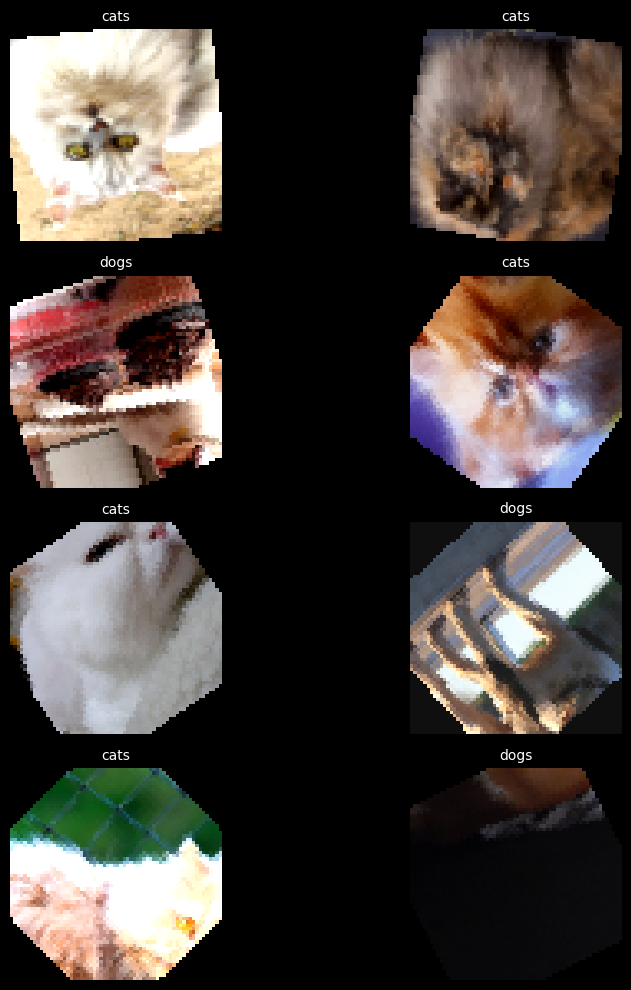

In [30]:
indices = np.random.choice(len(train_im_folder), num_images, replace=False)
images, labels = zip(*[train_im_folder[i] for i in indices])

fig, axs = plt.subplots(4, 2, figsize=(10, 10))
axs = axs.flatten()

for img, label, ax in zip(images, labels, axs):
    img_disp = img.permute(1, 2, 0) * 0.5 + 0.5  # denormalizacja
    ax.imshow(img_disp.numpy())
    ax.set_title(train_im_folder.classes[label], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Zadanie 2: Zaimplementuj sieć CNN na podstawie opisu architektury

**Cel:** Zrozumienie przekrojów przez architekturę oraz budowa modelu od podstaw w PyTorch.

**Opis architektury (MiniCNN):**

```
Wejście: RGB obraz 64x64
Blok 1: Conv(3→32, kernel=3, padding=1) + ReLU + MaxPool(2)
Blok 2: Conv(32→64, kernel=3, padding=1) + ReLU + MaxPool(2)
Blok 3: Conv(64→128, kernel=3, padding=1) + ReLU + MaxPool(2)
FC1: Linear(128×8×8 → 256) + ReLU
FC2: Linear(256 → 2)
```

- Zaimplementuj klasę `MiniCNN(nn.Module)`.
- Wytrenuj sieć na podstawie danych z poprzedniego ćwiczenia.

**Opcjonalnie (nie podlega ocenie):** Rozszerz sieć o dropout, batch normalization lub global average pooling, itd.